In [1]:
import os
from pathlib import Path

# Discover pairs of CT images and segmentation masks

image_dir = Path("/home/alonso/Documents/ccRCC/data/tcga_kirc_voi_f/img/")
mask_dir = Path("/home/alonso/Documents/ccRCC/data/tcga_kirc_voi_f/msk/")

# Find all CT images ending with _0000.nii.gz (recursively in all subfolders)
image_files = sorted(list(image_dir.rglob("*npy")))

# Create pairs by matching case names
pairs = []
for img_path in image_files:
    # Extract case name by removing _0000.nii.gz suffix
    case_name = img_path.stem
    
    # Look for corresponding mask file (recursively in mask_dir)
    mask_matches = list(mask_dir.rglob(f"{case_name}.npy"))
    
    if mask_matches:
        mask_path = mask_matches[0]  # Take first match
        pairs.append({
            'case_name': case_name,
            'image_path': str(img_path),
            'mask_path': str(mask_path)
        })
    else:
        print(f"Warning: No mask found for {case_name}")
print(f"\nFound {len(pairs)} image-mask pairs")


Found 319 image-mask pairs


In [2]:
import numpy as np
import re

# Compute volumes of tumor (mask=2) for all paired files
files_with_tumor = {}

voxel_spacing_mm = [1.0, 1.0, 1.0]  # [x, y, z] in mm
voxel_volume_mm3 = np.prod(voxel_spacing_mm)
voxel_volume_cm3 = voxel_volume_mm3 / 1000  # Convert mm³ to cm³

# Dictionary to store case-level information
case_summary = {}

for item in pairs:
    # Load mask
    mask = np.load(item['mask_path'])
    
    # Extract case ID using regex
    case_id_match = re.search(r'case_(\d{5})', item['case_name'])
    if case_id_match:
        case_id = case_id_match.group(1)
    else:
        case_id = 'unknown'
    
    # Determine kidney side from case name
    kidney_side = 'Right' if item['case_name'].endswith('_R') else 'Left'
    
    # Count voxels where mask == 2 (tumor)
    tumor_voxels = np.sum(mask == 2)
    
    # Initialize case summary if not exists
    if case_id not in case_summary:
        case_summary[case_id] = {'Left': 'no tumor', 'Right': 'no tumor'}
    
    # Only include if tumor is present
    if tumor_voxels > 0:
        volume = tumor_voxels * voxel_volume_cm3

        # compute bbox and compute the expected shape in 3D if we crop to bbox
        coords = np.argwhere(mask == 2)
        x_min, y_min, z_min = coords.min(axis=0)
        x_max, y_max, z_max = coords.max(axis=0)
        bbox = [x_min, x_max, y_min, y_max, z_min, z_max]

        # show the shape of final expected cropped volume
        expected_shape = (x_max - x_min + 1, y_max - y_min + 1, z_max - z_min + 1)
        
        # Store metadata in dictionary
        files_with_tumor[item['case_name']] = {
            'case_id': case_id,
            'kidney_side': kidney_side,
            'tumor_volume_cm3': volume,
            'tumor_voxels': int(tumor_voxels),
            'bbox': bbox,
            'expected_shape': expected_shape
        }
        
        # Update case summary
        case_summary[case_id][kidney_side] = 'tumor'

print(f"Patients with tumor: {len(files_with_tumor)}")
print(f"\nCase summary (case_id: {{Left: status, Right: status}}):")
for case_id, status in sorted(case_summary.items()):
    print(f"  case_{case_id}: {status}")

Patients with tumor: 209

Case summary (case_id: {Left: status, Right: status}):
  case_00083: {'Left': 'tumor', 'Right': 'tumor'}
  case_00087: {'Left': 'tumor', 'Right': 'no tumor'}
  case_00093: {'Left': 'tumor', 'Right': 'no tumor'}
  case_00096: {'Left': 'tumor', 'Right': 'no tumor'}
  case_00100: {'Left': 'tumor', 'Right': 'no tumor'}
  case_00104: {'Left': 'no tumor', 'Right': 'tumor'}
  case_00108: {'Left': 'no tumor', 'Right': 'tumor'}
  case_00112: {'Left': 'tumor', 'Right': 'no tumor'}
  case_00113: {'Left': 'no tumor', 'Right': 'no tumor'}
  case_00123: {'Left': 'tumor', 'Right': 'no tumor'}
  case_00124: {'Left': 'tumor', 'Right': 'no tumor'}
  case_00127: {'Left': 'no tumor', 'Right': 'no tumor'}
  case_00131: {'Left': 'tumor', 'Right': 'no tumor'}
  case_00132: {'Left': 'tumor', 'Right': 'tumor'}
  case_00148: {'Left': 'no tumor', 'Right': 'tumor'}
  case_00149: {'Left': 'no tumor', 'Right': 'tumor'}
  case_00150: {'Left': 'tumor', 'Right': 'tumor'}
  case_00151: {'Left'

In [4]:
import shutil
import json

# Create output directory for tumor cases
output_dir = Path("/home/alonso/Documents/ccRCC/data/tcga_kirc_voi_f_tumor/img/")
output_dir.mkdir(exist_ok=True, parents=True)

# Copy files with tumors to new directory, preserving subfolder structure
for case_name in files_with_tumor.keys():
    # Find the source file
    source_file = None
    matches = list(image_dir.rglob(f"{case_name}.npy"))
    if matches:
        source_file = matches[0]
    else:
        print(f"Warning: Could not find {case_name}.npy")
        continue
    
    # Get relative path from image_dir to preserve subfolder structure
    rel_path = source_file.relative_to(image_dir)
    
    # Create destination path with same subfolder structure
    dest_file = output_dir / rel_path
    dest_file.parent.mkdir(exist_ok=True, parents=True)
    
    # Copy the file
    shutil.copy(source_file, dest_file)

# Save metadata as JSON - convert numpy types to native Python types
metadata_to_save = {}
for case_name, data in files_with_tumor.items():
    metadata_to_save[case_name] = {
        'case_id': data['case_id'],
        'kidney_side': data['kidney_side'],
        'tumor_volume_cm3': float(data['tumor_volume_cm3']),
        'tumor_voxels': int(data['tumor_voxels']),
        'bbox': [int(x) for x in data['bbox']],
        'expected_shape': tuple(int(x) for x in data['expected_shape'])
    }

metadata_file = output_dir / "metadata.json"
with open(metadata_file, 'w') as f:
    json.dump(metadata_to_save, f, indent=2)
print(f"Copied {len(files_with_tumor)} files with tumors to {output_dir}")

Copied 209 files with tumors to /home/alonso/Documents/ccRCC/data/tcga_kirc_voi_f_tumor/img


In [4]:
# Read files from tumor directory and match with masks, then load metadata
tumor_files = sorted(list(output_dir.glob("*.npy")))

# Load metadata
with open(metadata_file, 'r') as f:
    tumor_metadata = json.load(f)

# Create matched pairs of tumor images and masks
tumor_pairs = []
for tumor_file in tumor_files:
    case_name = tumor_file.stem
    
    # Find corresponding mask file
    mask_file = mask_dir / "A" / f"{case_name}.npy"
    
    if mask_file.exists():
        tumor_pairs.append({
            'case_name': case_name,
            'image_path': str(tumor_file),
            'mask_path': str(mask_file),
            'metadata': tumor_metadata.get(case_name, {})
        })
    else:
        print(f"Warning: No mask found for {case_name}")

print(f"Found {len(tumor_pairs)} tumor image-mask pairs")
print(f"Loaded metadata for {len(tumor_metadata)} cases")

Found 165 tumor image-mask pairs
Loaded metadata for 165 cases


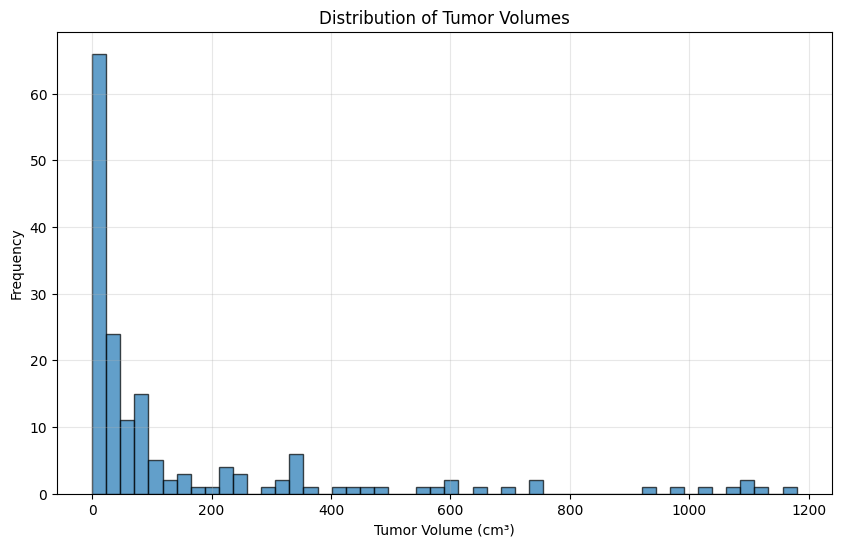

Number of tumors: 165
Min volume: 0.009 cm³
Max volume: 1179.957 cm³
Mean volume: 153.138 cm³
Median volume: 41.585 cm³


In [6]:
import matplotlib.pyplot as plt

# Extract tumor volumes from metadata
volumes = [data['tumor_volume_cm3'] for data in tumor_metadata.values()]

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(volumes, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Tumor Volume (cm³)')
plt.ylabel('Frequency')
plt.title('Distribution of Tumor Volumes')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Number of tumors: {len(volumes)}")
print(f"Min volume: {min(volumes):.3f} cm³")
print(f"Max volume: {max(volumes):.3f} cm³")
print(f"Mean volume: {np.mean(volumes):.3f} cm³")
print(f"Median volume: {np.median(volumes):.3f} cm³")

Tumor Volume Percentiles (cm³):
  5th percentile: 0.605 cm³
  10th percentile: 1.357 cm³
  25th percentile: 7.243 cm³
  50th percentile: 41.585 cm³
  75th percentile: 149.299 cm³
  95th percentile: 742.725 cm³

Filtered volumes (25th-75th percentile): 139 out of 165


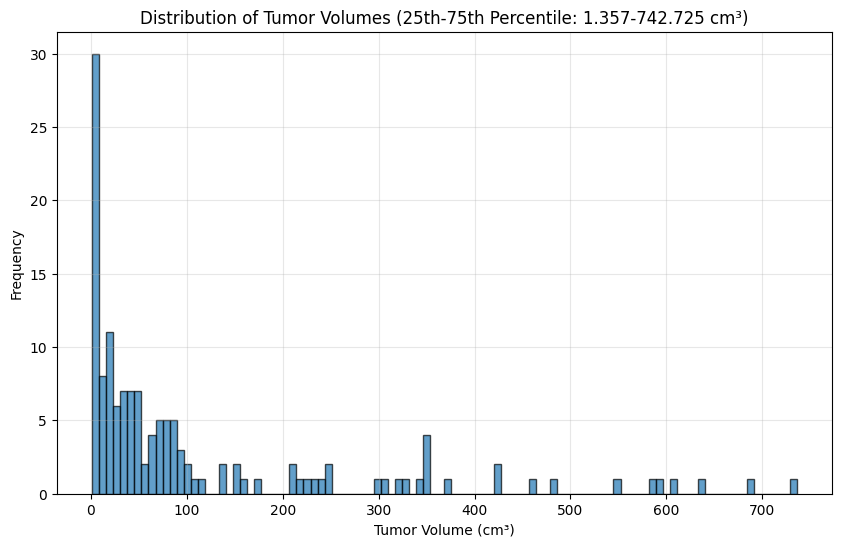


Filtered volume statistics:
Min: 1.374 cm³
Max: 735.849 cm³
Mean: 115.110 cm³
Median: 45.703 cm³
Count: 139

Percentile Analysis Table
Percentile   Volume (cm³)    Files ≤ P       Unique Cases ≤ P    
--------------------------------------------------------------------------------
5th         0.605           9               9                   
10th         1.357           17              14                  
25th         7.243           42              25                  
50th         41.585          83              39                  
75th         149.299         124             49                  
95th         742.725         156             54                  


In [10]:
# Calculate and print percentiles
percentiles = [5, 10, 25, 50, 75, 95]
percentile_values = np.percentile(volumes, percentiles)

print("Tumor Volume Percentiles (cm³):")
for p, v in zip(percentiles, percentile_values):
    print(f"  {p}th percentile: {v:.3f} cm³")

# Filter volumes between 25th and 75th percentiles
p25 = percentile_values[1]
p75 = percentile_values[-1]
filtered_volumes = [v for v in volumes if p25 <= v <= p75]

print(f"\nFiltered volumes (25th-75th percentile): {len(filtered_volumes)} out of {len(volumes)}")

# Create histogram of filtered volumes
plt.figure(figsize=(10, 6))
plt.hist(filtered_volumes, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Tumor Volume (cm³)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Tumor Volumes (25th-75th Percentile: {p25:.3f}-{p75:.3f} cm³)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFiltered volume statistics:")
print(f"Min: {min(filtered_volumes):.3f} cm³")
print(f"Max: {max(filtered_volumes):.3f} cm³")
print(f"Mean: {np.mean(filtered_volumes):.3f} cm³")
print(f"Median: {np.median(filtered_volumes):.3f} cm³")
print(f"Count: {len(filtered_volumes)}")

# Create table for percentile analysis
print("\n" + "="*80)
print("Percentile Analysis Table")
print("="*80)
print(f"{'Percentile':<12} {'Volume (cm³)':<15} {'Files ≤ P':<15} {'Unique Cases ≤ P':<20}")
print("-"*80)

for p, v in zip(percentiles, percentile_values):
    # Count files at or below this percentile
    files_at_percentile = sum(1 for vol in volumes if vol <= v)
    
    # Count unique case_ids at or below this percentile
    case_ids_at_percentile = set()
    for case_name, data in tumor_metadata.items():
        if data['tumor_volume_cm3'] <= v:
            # Extract case_id from metadata or case_name
            case_id = data.get('case_id', case_name.split('_case_')[1].split('_')[0] if '_case_' in case_name else 'unknown')
            case_ids_at_percentile.add(case_id)
    
    print(f"{p}th{'':<8} {v:<15.3f} {files_at_percentile:<15} {len(case_ids_at_percentile):<20}")

print("="*80)

In [18]:
"""
Radiomics extraction (pickle-free):
- Derives feature columns from what PyRadiomics actually returns.
- Drops diagnostics_* keys.
- Converts values to scalars safely.
- Skips cases without REQUIRED_LABEL in the mask.
- Writes a single CSV with consistent columns across all cases.
"""

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
from radiomics import featureextractor
from tqdm import tqdm
import re

# ------------------------------- Config ------------------------------- #
PARAMS_YAML = "/home/alonso/Documents/radiopatho_backup/radiomics_params.yaml"
IMAGE_ROOT  = Path("ukb2025_1_voi_tumor/")
MASK_ROOT   = Path("ukb2025_1_voi_masks/")
OUTPUT_CSV  = IMAGE_ROOT / "radiomics_features.csv"
FAILED_CSV  = IMAGE_ROOT / "failed_extractions.csv"
REQUIRED_LABEL = 2  # set to None to accept any non-zero mask
# --------------------------------------------------------------------- #

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 160)


def safe_float(x):
    """Convert scalars/arrays/lists to float if possible, else return np.nan."""
    try:
        if isinstance(x, (int, float, np.number)):
            return float(x)
        arr = np.asarray(x)
        if arr.size == 0:
            return np.nan
        return float(arr.reshape(-1)[0])
    except Exception:
        return np.nan


def clean_feature_dict(feat_dict):
    """Drop diagnostics_* keys and coerce values to floats."""
    out = {}
    for k, v in feat_dict.items():
        if k.startswith("diagnostics_"):
            continue
        val = safe_float(v)
        if np.isfinite(val):
            out[k] = val
    return out


def find_image_mask_pairs(image_root: Path, mask_root: Path, ext=".npy"):
    imgs = sorted(image_root.rglob(f"*{ext}"))
    pairs = []
    for img_path in imgs:
        rel = img_path.relative_to(image_root)  # keep subfolders
        mask_path = mask_root / rel
        if mask_path.exists():
            match = re.search(r'case_(\d{5})', img_path.stem)
            case_id = match.group(1) if match else img_path.stem
            pairs.append({
                "case_name": case_id,
                "file_name": img_path.stem,
                "side": "R" if img_path.stem.endswith("_R") else "L",
                "class_label": "NG",
                "image_path": img_path,
                "mask_path": mask_path,
            })
            # print(pairs)
        else:
            print(f"Warning: No mask found for {img_path.stem} at {mask_path}")
    return pairs


def main():
    # 1) Initialize extractor
    extractor = featureextractor.RadiomicsFeatureExtractor(PARAMS_YAML)
    print("\n=== PyRadiomics Extractor ===")
    print("Settings:", extractor.settings)
    print("Image types:", extractor.enabledImagetypes)
    print("Enabled features:", extractor.enabledFeatures)

    # 2) Pair images and masks
    pairs = find_image_mask_pairs(IMAGE_ROOT, MASK_ROOT, ext=".npy")
    print(f"\nFound {len(pairs)} image-mask pairs under {IMAGE_ROOT}")

    # 3) Extract
    records = []
    failed = []
    all_keys = set()

    for p in tqdm(pairs, desc="Extracting radiomics"):
        case_name = p["case_name"]
        class_label = p["class_label"]
        side = p["side"]

        try:
            img = np.load(p["image_path"]).squeeze()
            msk = np.load(p["mask_path"]).squeeze().astype(np.uint8)

            # Label check
            if REQUIRED_LABEL is None:
                if not np.any(msk):
                    failed.append({"case_name": case_name, "side": side, "reason": "mask_all_zero"})
                    continue
                label_for_exec = 1  # radiomics requires an integer label; binary mask assumed
                msk = (msk > 0).astype(np.uint8)
            else:
                if not np.any(msk == REQUIRED_LABEL):
                    failed.append({"case_name": case_name, "side": side, "reason": f"label_{REQUIRED_LABEL}_absent"})
                    continue
                label_for_exec = REQUIRED_LABEL

            itk_img = sitk.GetImageFromArray(img)
            itk_msk = sitk.GetImageFromArray(msk)

            feats_raw = extractor.execute(itk_img, itk_msk, label=label_for_exec)
            feats = clean_feature_dict(feats_raw)
            if not feats:
                failed.append({"case_name": case_name, "side": side, "reason": "no_features_returned"})
                continue

            all_keys.update(feats.keys())
            records.append({"case_name": case_name, "class": class_label, **feats})

        except Exception as e:
            failed.append({"case_name": case_name, "side": side, "reason": str(e)})

    # 4) Save
    if not records:
        print("\nNo successful extractions. Nothing to save.")
        if failed:
            pd.DataFrame(failed).to_csv(FAILED_CSV, index=False)
            print(f"Failed cases report saved to: {FAILED_CSV}")
        return

    feature_cols = sorted(all_keys)
    df = pd.DataFrame.from_records(records)
    df = df.reindex(columns=["file_name", "case_name", "side", "class"] + feature_cols)

    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved features to: {OUTPUT_CSV}")
    print(f"Shape: {df.shape} | Non-NaN entries: {df[feature_cols].notna().sum().sum()}")

    if failed:
        pd.DataFrame(failed).to_csv(FAILED_CSV, index=False)
        print(f"Failed cases report saved to: {FAILED_CSV}")

    print("\nClass distribution:")
    print(df["class"].value_counts(dropna=False))
    print("\nPreview:")
    print(df.head(3))


if __name__ == "__main__":
    main()



=== PyRadiomics Extractor ===
Settings: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': [1, 1, 1], 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': [-200, 300], 'label': 1, 'additionalInfo': True}
Image types: {'Original': {}}
Enabled features: {'shape': None, 'firstorder': None, 'glcm': None, 'glrlm': None, 'glszm': None, 'gldm': None, 'ngtdm': None}

Found 165 image-mask pairs under ukb2025_1_voi_tumor


Extracting radiomics: 100%|██████████| 165/165 [04:35<00:00,  1.67s/it]


Saved features to: ukb2025_1_voi_tumor/radiomics_features.csv
Shape: (165, 111) | Non-NaN entries: 17655

Class distribution:
class
NG    165
Name: count, dtype: int64

Preview:
   file_name case_name  side class  original_firstorder_10Percentile  original_firstorder_90Percentile  original_firstorder_Energy  \
0        NaN     00027   NaN    NG                              28.0                             144.0                  44470977.0   
1        NaN     00027   NaN    NG                             -10.0                              45.0                    428831.0   
2        NaN     00028   NaN    NG                              21.0                              98.0                 282601058.0   

   original_firstorder_Entropy  original_firstorder_InterquartileRange  original_firstorder_Kurtosis  ...  original_shape_Maximum2DDiameterColumn  \
0                     2.840190                                   61.00                      2.848955  ...                              